In [1]:
import os
import ast
import xarray as xr
import pandas as pd
import polars as pl
import numpy as np
import jax
import diffrax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
# analysis startdate
start_year = 1998
start_month = 9
end_year = 2026
assert start_year >= 1998, "earliest start_year is 1998."

# modeled municipalities
included_munis = [2611606, 2927408] # Recife and Salvador
age_groups = [(0, 1), (1, 6), (6, 12), (12, 18), (18, 25), (25,35), (35,55), (55,120)]
breaks = [end for _, end in age_groups[:-1]]
labels = [f"[{start}, {end})" for start, end in age_groups]

In [3]:
n_munis = len(included_munis)
n_age_groups = len(age_groups)
months = pd.date_range(start=f"{start_year}-{start_month:02d}-01", end=f"{end_year}-12-31", freq="ME")
n_months = len(months)
n_serotypes = 4

In [4]:
# TODO

## Seeding


## Model parameters

## Prepare the input data

In [5]:
# Compute population in start_year (n_munis, n_age_groups)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

demo = (
    pl.scan_parquet('../../data/interim/demographics/population_mun-age_1998-2026.parquet')
    .filter(pl.col("CD_MUN").is_in(included_munis))
    .filter(pl.col("year") == start_year)
    .with_columns(pl.col("age").cut(breaks=breaks, labels=labels, left_closed=True).alias("age_group"))
    .group_by([ "CD_MUN", "age_group"]).agg(pl.col("population").sum().alias("population"))
    .sort([ "CD_MUN", "age_group"])
    .collect()
)

# convert to jnp array
demo = demo.pivot(
    values="population",
    index="CD_MUN",
    on="age_group",
    aggregate_function="sum",
)

demo = jnp.array(demo.select(pl.exclude("CD_MUN")).to_numpy())

In [6]:
# Compute birth and death rates (n_months, n_munis, n_age_groups)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

# get raw data (yearly)
births = pd.read_csv('../../data/interim/demographics/births_mun_1998-2026.csv')
deaths = pd.read_csv('../../data/interim/demographics/deaths_mun_1998-2026.csv')
bd = births.merge(deaths, on=['CD_MUN', 'year', 'population'], how='left')
bd = bd[bd['CD_MUN'].isin(included_munis)]

# convert data to monthly data
bd['births'] /= 12
bd['death_rate'] = (bd['deaths'] / 12) / bd['population']

# expand to monthly timestep of the model
monthly_template = pd.MultiIndex.from_product([included_munis, months], names=["CD_MUN", "date"]).to_frame(index=False)
monthly_template["year"] = monthly_template["date"].dt.year
bd_monthly = pd.merge(monthly_template, bd, on=["CD_MUN", "year"], how="left")

# births (all in first age group)
births = jnp.array(bd_monthly.pivot(index="date", columns="CD_MUN", values="births").to_numpy())

# deaths (uniform death rate over age groups)
deaths_2d = bd_monthly.pivot(index="date", columns="CD_MUN", values="death_rate").to_numpy()
deaths = np.repeat(deaths_2d[:,:,None], len(age_groups), axis=-1)

In [ ]:
# Seeding and introduction masks (combined) (n_months, n_munis, n_serotypes)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

# load incidence data

# rolling window average


## Initial conditions

### Susceptible states (S)

In [7]:
def infection_history_from_foi(foi_year, age_groups):
    """
    Compute age- and municipality-specific infection-history probabilities
    from a constant force of infection per municipality.

    Parameters
    ----------
    foi_year : jnp.ndarray
        shape: (n_munis,)
        Annual force of infection for each municipality.
        
    age_groups : list[tuple]
        Age intervals as (lower_age, upper_age), e.g. [(0, 1), (1, 6), (6, 12), ...]

    Returns
    -------
    f_P : jnp.ndarray
        shape: (n_munis, n_age_groups, 3)
        Probability of having 0, 1, or >=2 prior infections for each municipality and age group.
    """
    
    midpoint_age = jnp.array([(lo + hi) / 2 for lo, hi in age_groups])

    foi = foi_year[:, None]     # foi: (n_munis, 1)
    age = midpoint_age[None, :] # age: (1, n_age_groups)

    # Poisson-process infection history
    cumulative_foi = foi * age
    P0 = jnp.exp(-cumulative_foi)
    P1 = cumulative_foi * jnp.exp(-cumulative_foi)
    P2plus = 1.0 - P0 - P1

    return jnp.stack([P0, P1, P2plus], axis=-1)

In [8]:
def build_initial_susceptibles(demo, f_P, pi_d, pi_mono2):
    """
    Construct initial susceptibles for 1999 (only DENV-1 and DENV-2)

    Parameters
    ----------
    demo : jnp.ndarray
        shape (n_munis, n_age_groups)
        population count

    f_P: jnp.ndarray
        shape (n_munis, n_age_groups)
        fraction of total population in cross-protected state

    pi_d : jnp.ndarray
        shape (n_munis, n_age_groups, 3)
        fraction of (muni,age) in degree of infection: [naive, mono, double]

    pi_mono2 : jnp.ndarray
        shape (n_munis, n_age_groups)
        fraction of mono infected by DENV-2

    Returns
    -------
    S0 : jnp.ndarray
        shape (n_munis, n_age_groups, 16)
        initial S states
    """
    
    z = jnp.zeros_like(pi_d[..., 0])                                   # (n_munis, n_age_groups)
    S_frac = jnp.stack([pi_d[..., 0],
                       pi_d[..., 1] * (1 - pi_mono2),
                       pi_d[..., 1] * pi_mono2,
                       z, z,
                       pi_d[..., 2]] + [z] * 10, axis=-1)             # (n_munis, n_age_groups, 16)
    return (1 - f_P)[..., None] * demo[..., None] * S_frac


In [9]:
f_P = 0.25 * jnp.ones([n_munis, n_age_groups])
pi_mono2 = 0.33 * jnp.ones([n_munis, n_age_groups])
pi_d = infection_history_from_foi(jnp.array([0.05, 0.05]), age_groups)
S0 = build_initial_susceptibles(demo, f_P, pi_d, pi_mono2) # (n_munis, n_age_groups, 16)

### Cross-protected states (P)

In [10]:
def build_initial_crossprotection(demo, f_P, pi_d, f_P2):
    """
    Construct the initial cross-protected state (only DENV-1 and DENV-2 histories).

    Parameters
    ----------
    demo : jnp.ndarray
        shape (n_munis, n_age_groups)
        population count

    f_P : jnp.ndarray
        shape (n_munis, n_age_groups)
        fraction of total population in cross-protected state

    pi_d : jnp.ndarray
        shape (n_munis, n_age_groups, 3)
        fraction of (muni,age) in degree of infection: [naive, mono, double]

    f_P2 : jnp.ndarray
        shape (n_munis, n_age_groups)
        fraction of the cross-protected population that is protected after a DENV-2 infection

    Returns
    -------
    P0 : jnp.ndarray
        shape (n_munis, n_age_groups, 32)
    """
    # normalize pi_d over degree of infection 1 and 2
    pi_sum = pi_d[..., 1] + pi_d[..., 2] + 1e-12         # prevent division by zero
    deg1_frac = pi_d[..., 1] / pi_sum                    # (n_munis, n_age_groups)
    deg2_frac = pi_d[..., 2] / pi_sum                    

    # P states: 0 = P_1^∅, 1 = P_2^∅, 4 = P_2^1, 7 = P_1^2; all other states start empty
    z = jnp.zeros_like(f_P2)
    P_frac = jnp.stack([deg1_frac * (1 - f_P2), deg1_frac * f_P2, z, z,
                        deg2_frac * f_P2, z, z, deg2_frac * (1 - f_P2)]
                       + [z] * 24, axis=-1)              

    return (f_P * demo)[..., None] * P_frac

In [11]:
f_P2 = 0.33 * jnp.ones([n_munis, n_age_groups])
P0 = build_initial_crossprotection(demo, f_P, pi_d, f_P2)

### Infected states (I)

In [12]:
def build_initial_infected(demo, I_estim, p0, pi_d):
    """
    Parameters
    ----------

    demo : jnp.ndarray
        shape (n_munis, n_age_groups)
        population count

    I_estim: jnp.ndarray
        shape: (n_munis,)
        fraction of population infected
        (assumed uniform over age groups)
    
    p0: jnp.ndarray
        shape: (n_clusters, n_serotypes)
        initial serotype distribution 
        
    pi_d : jnp.ndarray
        shape (n_munis, n_age_groups, 3)
        fraction of (muni,age) in degree of infection: [naive, mono, double]

    Returns
    -------
    I0 : jnp.ndarray
        shape (n_munis, n_age_groups, 32)
    """

    # divide the total dengue cases over the serotypes under the assumption they are heterologous infections
    I_estim_star = ((I_estim[:, None] * demo)[:, :, None] * p0[:,None,:])[:, :, None, :] * jnp.stack([ pi_d[..., 0],  pi_d[..., 1],  pi_d[..., 2], jnp.zeros_like(pi_d[..., 0]), jnp.zeros_like(pi_d[..., 0])], axis=-1)[:, :, :, None]
    # shape: n_munis, n_age_groups, n_prior_heterologous infections, n_serotypes

    z = jnp.zeros_like(I_estim_star[:, :, 0, 0])
    return jnp.stack([I_estim_star[:, :, 0, 0], I_estim_star[:, :, 0, 1], I_estim_star[:, :, 0, 2], I_estim_star[:, :, 0, 3], # naive
                          I_estim_star[:, :, 1, 1], I_estim_star[:, :, 1, 2], I_estim_star[:, :, 1, 3],                       # one prior DENV 1
                          I_estim_star[:, :, 1, 0], I_estim_star[:, :, 1, 2], I_estim_star[:, :, 1, 3],                       # one prior DENV 2
                            z, z, z, z, z, z,
                              I_estim_star[:, :, 2, 2], I_estim_star[:, :, 2, 3],                                             # two prior DENV 1 + 2
                                  z, z, z, z, z, z, z, z, z, z, z, z, z, z], axis=-1)


In [13]:
I_estim = jnp.array([1e-5, 1e-5])
p0 = jnp.array([[0.90, 0.09, 0.009, 0.001], [1, 0, 0, 0]])
I0 = build_initial_infected(demo, I_estim, p0, pi_d)

## Time-dependent parameters

### beta_monthly

In [14]:
mu_beta = jnp.array([jnp.log(2.0), jnp.log(2.0)])
A_beta = jnp.array([1, 1])
phi_beta = jnp.array([jnp.pi/2, jnp.pi/2])
season = A_beta[None, :] * jnp.cos(2 * np.pi * jnp.arange(len(months))[:, None] / 12 - phi_beta[None, :])
beta_monthly = jnp.exp(mu_beta[None, :] + season)

### births_monthly

In [15]:
births_monthly = births

### deaths_monthly

In [16]:
deaths_monthly = deaths

### f_monthly

In [17]:
f = jnp.array([0.6, 0.5, 0.5, 0.5])
f_monthly = jnp.broadcast_to(f, (n_months, n_munis, n_serotypes))

## Construct the transition matrices

In [18]:
# Load in the transmission model state mappings
## susceptibles
S_mapping = pd.read_csv(f'../../data/raw/transmission_model/susceptible_states.csv')
list_columns = ["susc_to_heterol_inf", "susc_to_homol_inf"]
# Convert strings to actual lists
for col in list_columns:
    S_mapping[col] = S_mapping[col].apply(ast.literal_eval)
## infectious/protected
IP_mapping = pd.read_csv(f'../../data/raw/transmission_model/infectious_protected_states.csv')

In [19]:
# Generate the matrices used to update the system

## define lengths
n_I = len(IP_mapping)
n_S = len(S_mapping)

## I-update-indices
sero_idx = IP_mapping["currently_infected_with"].values - 1

## births
birth_vec = jnp.zeros([n_age_groups, n_S])
birth_vec = birth_vec.at[0,0].set(1.0)

## C --> Maps infected states onto serotypes
C = np.zeros((n_I, n_serotypes))
C[np.arange(n_I), sero_idx] = 1.0
C = jnp.array(C)

## W --> Maps protected states waning to S
W = jnp.array(np.eye(n_S)[IP_mapping["P_to_S"]])

## Susceptibility of S states to serotypes (M = H_het + f * H_hom)
H_het = jnp.zeros((n_S, n_serotypes))
H_hom = jnp.zeros((n_S, n_serotypes))
for j, row in S_mapping.iterrows():
    for k in row["susc_to_heterol_inf"]:
        H_het = H_het.at[j, int(k)-1].set(1.0)
    for k in row["susc_to_homol_inf"]:
        H_hom = H_hom.at[j, int(k)-1].set(1.0)
H_het = jnp.transpose(H_het)
H_hom = jnp.transpose(H_hom)

## Flow of S states into I states (heterologous and homologous)
K_het = jnp.zeros((n_I, n_S))
K_hom = jnp.zeros((n_I, n_S))
for i, row in IP_mapping.iterrows():
    K_het = K_het.at[i, int(row["S_to_I_heterol"])].set(1.0)
    K_hom = K_hom.at[i, int(row["S_to_I_homol"])].set(1.0)
K_het = jnp.transpose(K_het)
K_hom = jnp.transpose(K_hom)

## Map serotype-specific FOI to the per I state FOI
L = jnp.zeros((n_serotypes, n_I))
for i, s in enumerate(IP_mapping["currently_infected_with"].values - 1):
    L = L.at[s, i].set(1.0)

# Compute the aging matrix (n_age_groups x n_age_groups)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

# compute widths in months
widths_months = np.array([(b[1] - b[0]) * 12 for b in age_groups])

# compute aging rates (1 / width)
aging_rates = np.zeros(len(age_groups))
aging_rates[:-1] = 1.0 / widths_months[:-1]

# build the transition matrix (n_groups x n_groups)
A_aging = np.zeros((len(age_groups), len(age_groups)))
np.fill_diagonal(A_aging, -aging_rates) # negative outflows on the diagonal
for i in range(len(age_groups) - 1):
    A_aging[i + 1, i] = aging_rates[i] # positive inflows on the sub-diagonal

# convert to jnp array
A = jnp.array(A_aging)

## Construct post-simulation state mapping #TODO

In [20]:
# post-hoc observation mapping
## Delta_I mapping to (cluster, degree, serotype)
O = jnp.zeros((n_I, IP_mapping["no_prior_heterol_inf"].max() + 1, n_serotypes))
for i, row in IP_mapping.iterrows():
    d = int(row["no_prior_heterol_inf"])
    s = int(row["currently_infected_with"]) - 1
    O = O.at[i, d, s].set(1.0)

## S (slots) mapping to (cluster, degree, serotype)
### make two maps: one to heterologous and one to homologous 
### susceptibility slots = heterologous + f_i * homologous
R_het = jnp.zeros((n_S, S_mapping["no_prior_heterol_inf"].max() + 1, n_serotypes))
R_hom = jnp.zeros((n_S, S_mapping["no_prior_heterol_inf"].max() + 1, n_serotypes))
for i, row in S_mapping.iterrows():
    d = int(row["no_prior_heterol_inf"])
    for s in row["susc_to_heterol_inf"]:
        R_het = R_het.at[i, d, s-1].set(1.0)
    for s in row["susc_to_homol_inf"]:
        R_hom = R_hom.at[i, d, s-1].set(1.0)

## S (individuals) mapping to (cluster, degree)
D = jnp.zeros((n_S, S_mapping["no_prior_heterol_inf"].max() + 1))
for i, row in S_mapping.iterrows():
    D = D.at[i, int(row["no_prior_heterol_inf"])].set(1.0)

## Write the RHS function

In [21]:
def RHS(t, y, args):
    """
    Continuous-time derivatives for one spatial unit across age groups.

    Inputs: y, args (see `simulate_one_jax`)
    Returns dS_dt (n_age_groups, n_S), dI_dt (n_age_groups, n_I), dP_dt (n_age_groups, n_P),
            dC_hom (n_age_groups, n_I), dC_het (n_age_groups, n_I)
    """
    
    # unpack states
    S_t, I_t, P_t, _, _ = y
    
    # unpack parameters
    beta_monthly, births_monthly, deaths_monthly, f_monthly, A, C, W, H_het, H_hom, L, K_het, K_hom, birth_vec, gamma, omega, ts = args
    
    # look up beta, births and deaths, and seeding (jnp.interp)
    beta_t = jnp.interp(t, xp=ts, fp=beta_monthly)
    births_t = jnp.interp(t, xp=ts, fp=births_monthly)
    deaths_t = jax.vmap(lambda x: jnp.interp(t, ts, x))(deaths_monthly.T)
    f_t = jax.vmap(lambda x: jnp.interp(t, ts, x))(f_monthly.T)
    # TODO: add seeding
    
    # --- FOI: shared across age groups --------------------------------------------
    N_t = S_t.sum() + I_t.sum() + P_t.sum()                                    # scalar
    I_per_sero = I_t.sum(axis=0) @ C                                           # (n_serotypes,)
    lambda_t = beta_t * I_per_sero / N_t                                       # (n_serotypes,)
                                                                               # TODO: seeding (n_serotypes)

    # --- Susceptible --------------------------------------------------------------
    effective_lambda = lambda_t @ H_het + (lambda_t * f_t) @ H_hom             # (n_S,)
    dS_dt = (births_t * birth_vec
             - deaths_t[:, None] * S_t
             + (1.0 / omega) * (P_t @ W)
             - effective_lambda[None, :] * S_t
             + A @ S_t)                                                        # (n_age_groups, n_S)
 
    # --- Infectious ---------------------------------------------------------------
    f_per_I = f @ L                                                            # (n_I,)
    lambda_per_I = lambda_t @   L                                              # (n_I,)
    dI_het_dt = lambda_per_I[None, :] * (S_t @   K_het)                      # (n_age_groups, n_I)
    dI_hom_dt = lambda_per_I[None, :] * f_per_I[None, :] * (S_t @ K_hom)     # (n_age_groups, n_I)
    dI_dt = (- deaths_t[:, None] * I_t
            - (1 / gamma) * I_t
            + dI_het_dt + dI_hom_dt
            + A @ I_t)

    # --- Cross-protected ----------------------------------------------------------
    dP_dt = (- (1 / omega) * P_t
            - deaths_t[:, None] * P_t
            + (1 / gamma) * I_t
            + A @ P_t)

    return dS_dt, dI_dt, dP_dt, dI_het_dt, dI_hom_dt

## Write the diffrax single-municipality simulator

In [22]:
def simulate_jax_single(gamma, omega,
                        A, C, W, L, H_het, H_hom, K_het, K_hom, birth_vec, 
                        beta_monthly, births_monthly, deaths_monthly, f_monthly,
                        S0, I0, P0,
                        ts, stepsize):
    
    """
    Simulate one age-structured dengue transmission model.

    Parameters
    ----------
    gamma: scalar
        Duration of infection.
        
    omega: scalar
        Duration of cross protection.
        
    A: jnp.ndarray
        (n_age_groups, n_age_groups)
        Aging transition matrix.
        
    C: jnp.ndarray
        (32, n_serotypes)
        Maps infected states onto serotypes.

    W: jnp.ndarray
        (32, 16)
        Maps how P states wane to S states.

    L: jnp.ndarray
        (4, 32)
        Map serotype-specific FOI to the per I state FOI.

    H_het / H_hom: jnp.ndarray
        (16, 4)
         Susceptibility of S states to serotypes.
            
    K_het / K_hom : jnp.ndarray
        (16, 32)
        Flow of S states into I states.
               
    birth_vec: jnp.ndarray
        (n_age_groups, 16)
        All elements zero except at index (0,0).
        
    beta_monthly: jnp.ndarray
        (n_months,)
        Time-varying transmission rate.
        
    births_monthly: jnp.ndarray
        (n_months,)
        Time-varying number of births.
        
    deaths_monthly: jnp.ndarray
        (n_months,)
        Time-varying number of deaths.
        
    f_monthly: jnp.ndarray
        (n_months, n_age_groups)
        Time-varying homologous reinfection probability.
        
    S0 : jnp.ndarray
        (n_age_groups, 16)
        Initial susceptibles.
        
    I0 : jnp.ndarray
        (n_age_groups, 32)
        Initial infected.

    P0: jnp.ndarray
        (n_age_groups, 32)
        Initial cross-protected.

    ts : array
        Simulation and observation dates.

    stepsize: float
        Simulation stepsize (fixed)

    Returns
    -------
    ys : jnp.ndarray
        ...
    """

    # Create diffrax term
    term = diffrax.ODETerm(RHS)

    # Solve
    sol = diffrax.diffeqsolve(
        term,
        diffrax.Bosh3(),
        t0=ts[0],
        t1=ts[-1],
        dt0=stepsize,
        y0=(S0, I0, P0, jnp.zeros_like(I0), jnp.zeros_like(I0)),
        args=(beta_monthly, births_monthly, deaths_monthly, f_monthly, A, C, W, H_het, H_hom, L, K_het, K_hom, birth_vec, gamma, omega, ts),
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.ConstantStepSize(),
        adjoint=diffrax.DirectAdjoint(),
    )

    return sol

## `vmap` single-municipality simulator over municipalities

In [23]:
def batch_jax_single(gamma, omega,
                        A, C, W, L, H_het, H_hom, K_het, K_hom, birth_vec, 
                        beta_monthly, births_monthly, deaths_monthly, f_monthly,
                        S0, I0, P0,
                        ts, stepsize):
    
    """
    Batch age-structured dengue transmission model over spatial units
    """
    
    simulation = jax.vmap(
        simulate_jax_single,
        in_axes=(
            None,   # gamma (scalar)
            None,   # omega (scalar)
            None,   # A
            None,   # C 
            None,   # W
            None,   # L
            None,   # H_het
            None,   # H_hom
            None,   # K_het
            None,   # K_hom
            None,   # birth_vec
            1,      # beta_monthly (n_months, n_munis)
            1,      # births_monthly (n_months, n_munis)
            1,      # deaths_monthly (n_months, n_munis, n_serotypes)
            1,      # f_monthly (n_months, n_munis, n_serotypes)
            0,      # S0 (n_munis, n_age_groups, 16)
            0,      # I0 (n_munis, n_age_groups, 32)       
            0,      # P0 (n_munis, n_age_groups, 32)
            None,   # ts
            None,   # stepsize
        ),
    )
    
    return simulation(gamma, omega, A, C, W, L, H_het, H_hom, K_het, K_hom, birth_vec, beta_monthly, births_monthly, deaths_monthly, f_monthly, S0, I0, P0, ts, stepsize)

## Run the model

In [24]:
stepsize = 0.25
assert ((stepsize > 0) & (stepsize <= 0.5)), "`stepsize` must be in interval )0, 0.5]"
ts = jnp.arange(n_months)
gamma = 0.5
omega = 18
kappa = jnp.ones([n_munis, n_age_groups, 4, n_serotypes]) # (cluster, age_group, infection_degree, serotype)

In [25]:
sol = batch_jax_single(
    gamma, omega,
    A, C, W, L, H_het, H_hom, K_het, K_hom, birth_vec, 
    beta_monthly, births_monthly, deaths_monthly, f_monthly,
    S0, I0, P0,
    ts, stepsize
)

In [26]:
# extract solutions
S, I, P, C_het, C_hom = sol.ys

# differentiate cumulative incidence of heterologeous and homologeous infections
dI_hom = jnp.concatenate([C_hom[:, :1], jnp.diff(C_hom, axis=1)], axis=1)
dI_het = jnp.concatenate([C_het[:, :1], jnp.diff(C_het, axis=1)], axis=1)

# reconstruct the FOI
N = S.sum(axis=(-2, -1)) + I.sum(axis=(-2, -1)) + P.sum(axis=(-2, -1)) # total population
I_per_sero = I.sum(axis=2) @ C # total infectious population by serotype
lambda_t = beta_monthly.T[..., None] * I_per_sero / N[..., None] # force of infection

# expand the S and I states
## reshape dI_het (cluster, time, age, I_state) --> (time, cluster, age_group, infection_degree, serotype, hom/het infection) 
dI_expanded = jax.nn.softplus(jnp.stack([jnp.einsum("ctai,ids->tcads", dI_hom, O), jnp.einsum("ctai,ids->tcads", dI_het, O)], axis=-1))

## reshape S into susceptibility slots per (time, cluster, age_group, infection_degree, serotype, hom/het infection)
S_expanded = jnp.stack([jnp.einsum("ctai,ids->tcads", S, R_hom), jnp.einsum("ctai,ids,tcs->tcads", S, R_het, f_monthly)], axis=-1)

# compute derived products
## compute observed number of cases per serotype
dI_obs_sero = jnp.sum(dI_expanded * kappa[None,][...,None], axis=(-1, -3)) # (time, cluster, age_group, serotype)
dI_obs = jnp.sum(dI_expanded * kappa[None,][...,None], axis=(-1, -2, -3)) # (time, cluster, age_group)

## compute "true" serotype proportions (time, cluster, serotype)
p_true = I_per_sero / jnp.sum(I_per_sero, axis=-1)[:, :, None]

## compute observed serotyped proportions (time, cluster, serotype)
p_obs = jnp.sum(dI_obs_sero, axis=-2) / jnp.sum(dI_obs_sero, axis=(-2,-1))[..., None]

In [27]:
simout = xr.Dataset(
    {
        # model states and incidences
        "S": (
            ["CD_MUN", "date", "age_group", "S_disease_state"],
            S,
        ),
        "I": (
            ["CD_MUN", "date", "age_group", "IP_disease_state"],
            I,
        ),
        "P": (
            ["CD_MUN", "date", "age_group", "IP_disease_state"],
            P,
        ),
        "dI_het": (
            ["CD_MUN", "date", "age_group", "IP_disease_state"],
            dI_het
        ),
        "dI_hom": (
            ["CD_MUN", "date", "age_group", "IP_disease_state"],
            dI_hom
        ),
        # expanded states
        "S_expanded": (
            ["date", "CD_MUN", "age_group", "n_prior_het_infections", "serotype", "infection_type"],
            S_expanded,
        ),    
        "dI_expanded": (
            ["date", "CD_MUN", "age_group", "n_het_infections", "serotype", "infection_type"],
            dI_expanded,
        ),          
        # latent derived states
        "lambda_t": (
            ["CD_MUN", "date", "serotype"],
            lambda_t
        ),
        "p_true": (
            ["CD_MUN", "date", "serotype"],
            p_true
        ),
        # observations
        "dI_obs": (
            ["date", "CD_MUN", "age_group"],
            dI_obs
        ),   
        "p_obs": (
            ["date", "CD_MUN", "serotype"],
            p_obs
        ),        
    },
    coords={
        "CD_MUN": included_munis,
        "date": months,
        "age_group": labels,
        "S_disease_state": S_mapping["name"],
        "IP_disease_state": IP_mapping["name"],
        "serotype": [1,2,3,4],
        "n_prior_het_infections": [0, 1, 2, 3, 4],
        "n_het_infections": [1, 2, 3, 4],
        "infection_type": ['hom','het']
    },
)

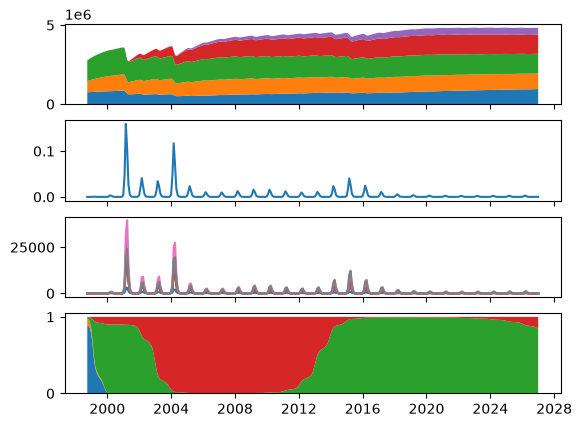

In [30]:
fig,ax = plt.subplots(nrows=4, ncols=1, sharex=True)

ax[0].stackplot(simout.date, np.transpose(simout["S_expanded"].sum(dim=["age_group", "serotype", "infection_type"]).sel(CD_MUN=2611606).values))
ax[1].plot(simout.date, simout["lambda_t"].sel(CD_MUN=2611606).sum(dim='serotype'))
ax[2].plot(simout.date, simout["dI_obs"].sel(CD_MUN=2611606))
ax[3].stackplot(simout.date, np.transpose(simout["p_true"].sel(CD_MUN=2611606).values))
plt.show()
plt.close()